In [ ]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import torch
import PIL.Image as Image
import torchvision
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings('ignore')
from sklearn import svm
from scipy.stats import ttest_ind

face_mask_VTC = np.load(r'face_mask.npy')
object_mask_VTC = np.load(r'object_mask.npy')

# Manifold

In [2]:
def barplot(data):
    """data: such as (5,20)"""
    palette = ['#fddbb2', '#d6e1e5']
    # 可视化设置
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 11,
        'axes.linewidth': 1.5
    })
    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=(2,4.5), dpi=100)
    # bar chart
    sns.barplot(data=data, alpha=1.0, palette=palette, errorbar='se', capsize=0.1)
    # 坐标轴装饰
    ax.set_xticks([0,1],['vlPFC', 'VTC'], rotation=30)
    ax.spines['top'].set_visible(False)    # 隐藏上边框
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    plt.annotate('', 
                 xy=(1.15, 0), xycoords='axes fraction',
                 xytext=(-0.06, 0), textcoords='axes fraction',
                 arrowprops=dict(facecolor='black', width=2.5, shrink=0.05),
                 zorder=5)
    # 绘制 y 轴方向的箭头
    plt.annotate('', 
                 xy=(0, 1.1), xycoords='axes fraction',
                 xytext=(0, -0.06), textcoords='axes fraction',
                 arrowprops=dict(facecolor='black', width=2.5, shrink=0.05),
                 zorder=5)
    plt.show()

29.69625375697755 0.5485197072547153 15.078613299999997 0.41314915099616933
Ttest_indResult(statistic=20.74759654793236, pvalue=2.5099757503101524e-22)


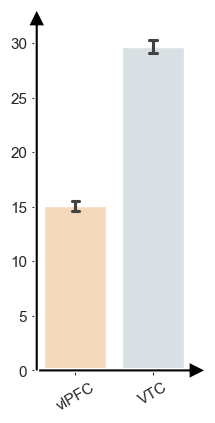

In [8]:
dimensions_VTC = np.load(r'model_dimensions_VTC.npy')
dimensions_vlPFC = np.load(r'model_dimensions_vlPFC.npy')
dimensions = np.hstack((dimensions_vlPFC.reshape(-1,1),
                        dimensions_VTC.reshape(-1,1)))
print(dimensions_VTC.mean(), dimensions_VTC.std()/np.sqrt(20), dimensions_vlPFC.mean(), dimensions_vlPFC.std()/np.sqrt(20))
print(ttest_ind(dimensions_VTC, dimensions_vlPFC))
barplot(dimensions)

0.858021142816131 0.007149664556317667 0.9994236000000001 0.006236664253589414
Ttest_indResult(statistic=-14.526617125648997, pvalue=4.271330259824189e-17)


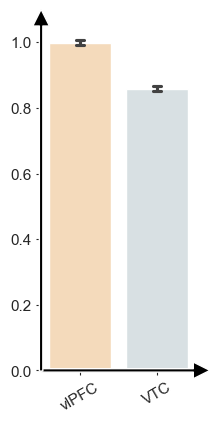

In [11]:
radii_VTC = np.load(r'model_radii_VTC.npy')
radii_vlPFC = np.load(r'model_radii_vlPFC.npy')
radii = np.hstack((radii_vlPFC.reshape(-1,1),
                   radii_VTC.reshape(-1,1)))
print(radii_VTC.mean(), radii_VTC.std()/np.sqrt(20), radii_vlPFC.mean(), radii_vlPFC.std()/np.sqrt(20))
print(ttest_ind(radii_VTC, radii_vlPFC))
barplot(radii)

# Decoding analysis

In [12]:
### Decoding as fMRI data
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = torchvision.models.alexnet(pretrained=True).to(device)
model.eval()

def prepare_data_for_nn(class1_data, class2_data, class3_data, class4_data, class5_data, class6_data):
    # Create labels for the two classes
    y_class1_test = np.zeros(class1_data.shape[0])    # Label 0 for class 1
    y_class2_test = np.zeros(class2_data.shape[0])     # Label 1 for class 2
    y_class3_test = np.zeros(class3_data.shape[0])    # Label 0 for class 1
    y_class4_test = np.zeros(class4_data.shape[0])     # Label 1 for class 2
    y_class5_test = np.zeros(class5_data.shape[0])    # Label 0 for class 1
    y_class6_test = np.ones(class6_data.shape[0])     # Label 1 for class 2

    # Combine training data and labels for both classes
    X_train = np.vstack((class1_data, class6_data))
    y_train = np.hstack((y_class1_test, y_class6_test))

    # Combine testing data and labels for both classes
    X_test = np.vstack((class1_data, class2_data, class3_data, class4_data, class5_data, class6_data))
    y_test = np.hstack((y_class1_test, y_class2_test, y_class3_test,
                        y_class4_test, y_class5_test, y_class6_test))

    # Shuffle the training data
    shuffled_indices = np.random.permutation(X_train.shape[0])
    X_train = X_train[shuffled_indices]
    y_train = y_train[shuffled_indices]

    return X_train, y_train, X_test, y_test

def test(X_test, y_test, classifier): 
    if type(classifier)==svm._classes.SVC:    
        outputs = classifier.predict(X_test)
        ACC = []
        for index in [range(0,20),range(20,40),range(40,60),range(60,80),range(80,100),range(100,120)]:
            acc = np.mean(outputs[index]==y_test[index])
            ACC.append(acc)
    if type(classifier)==torch.nn.modules.container.Sequential:
        X_test = torch.Tensor(X_test).to(device)
        y_test = torch.Tensor(y_test).to(device)
        out = classifier.forward(X_test)
        _, outputs = torch.max(out, 1)
        ACC = []
        for index in [range(0,20),range(20,40),range(40,60),range(60,80),range(80,100),range(100,120)]:
            acc = np.mean(outputs.cpu().data.numpy()[index]==y_test.cpu().data.numpy()[index])
            ACC.append(acc)
    return np.array(ACC)

def Score(FFA_face, FFA_noeye, FFA_top, FFA_down, FFA_eye, FFA_tool, model='nn'):
    """ FFA_face: is a shape of (samples, stimuli, neurons) """
    if model=='svm':
        X_train, y_train, X_test, y_test = prepare_data_for_nn(FFA_face, FFA_noeye, FFA_top, 
                                                               FFA_down, FFA_eye, FFA_tool)
        clf = svm.SVC(kernel='rbf')
        clf.fit(X_train, y_train)
        ACC_test = test(X_test, y_test, clf) 
    if model=='nn':
        classifier = torch.nn.Sequential(torch.nn.Linear(FFA_face.shape[1], 100, bias=True),
                                         torch.nn.Linear(100, 2, bias=True)).to(device) 
        optimizer = torch.optim.Adam(classifier.parameters(), lr=0.01)
        loss_function = torch.nn.CrossEntropyLoss()  
        X_train, y_train, X_test, y_test = prepare_data_for_nn(FFA_face, FFA_noeye, FFA_top, 
                                                               FFA_down, FFA_eye, FFA_tool)
        num_epoches = 10
        for epoch in range(num_epoches):  
            for inputs, targets in zip(X_train, y_train.reshape(-1,1)):
                inputs = torch.Tensor(inputs).to(device).unsqueeze(0)
                targets = torch.LongTensor(targets).to(device)
                out = classifier.forward(inputs)  
                loss = loss_function(out, targets) 
                optimizer.zero_grad()  
                loss.backward()  
                optimizer.step()
        ACC_test = test(X_test, y_test, classifier)

    return ACC_test

def load_Dynamics_state(load_dir, mode, key):
    results_dir = [load_dir+'Face_'+mode+'_results.npy',
                   load_dir+'Top_face_'+mode+'_results.npy',
                   load_dir+'Noeye_'+mode+'_results.npy',
                   load_dir+'Down_face_'+mode+'_results.npy',
                   load_dir+'Eyes_'+mode+'_results.npy',
                   load_dir+'Tool_'+mode+'_results.npy']
    Dynamics_states_VTC = [np.load(i,allow_pickle=True)[key] for i in results_dir]
    return Dynamics_states_VTC

def barplot(data):
    """data: such as (5,20)"""
    palette = ['#2f455c', '#39678d', '#5c898e', '#86aaa0', '#b5cdb5']
    plt.rcParams['font.family'] = 'Arial'       # 设置全局字体为无衬线字体Arial
    plt.rcParams['font.size'] = 12              # 全局字体大小8pt（根据期刊要求调整）
    plt.rcParams['axes.linewidth'] = 1.5       # 坐标轴线宽1.5pt
    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=(3,5), dpi=100)
    sns.barplot(data=data, alpha=1.0, palette=palette, errorbar='se', capsize=0.1)
    ax.set_xticks([0,1,2,3,4],['Intact', 'noEyes', 'Upper', 'Lower', 'Eyes'], rotation=30)
    ax.spines['top'].set_visible(False)    # 隐藏上边框
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    plt.annotate('', 
                 xy=(1.1, 0), xycoords='axes fraction',
                 xytext=(-0.06, 0), textcoords='axes fraction',
                 arrowprops=dict(facecolor='black', width=2.5, shrink=0.05),
                 zorder=5)
    # 绘制 y 轴方向的箭头
    plt.annotate('', 
                 xy=(0, 1.1), xycoords='axes fraction',
                 xytext=(0, -0.06), textcoords='axes fraction',
                 arrowprops=dict(facecolor='black', width=2.5, shrink=0.05),
                 zorder=5)
    plt.ylim([-1,1])
    plt.show()

def plot_6_condition_timeseries(mode, region, Dynamics_states):
    palette = ['#2f455c', '#39678d', '#5c898e', '#86aaa0', '#b5cdb5']
    def stats_value1(x, region):
        face_timeseries = x[:,:,np.where(face_mask_VTC==1)[0], np.where(face_mask_VTC==1)[1]].mean(axis=2)
        object_timeseries = x[:,:,np.where(object_mask_VTC==1)[0], np.where(object_mask_VTC==1)[1]].mean(axis=2)
        return (face_timeseries-object_timeseries)/2
    def stats_value2(x, region):
        face_timeseries = x[:,:,np.where(face_mask_VTC==1)[0], np.where(face_mask_VTC==1)[1]].mean(axis=2)
        else_timeseries = x[:,:,np.where(face_mask_VTC==-1)[0], np.where(face_mask_VTC==-1)[1]].mean(axis=2)
        return (face_timeseries-else_timeseries)/2
    def stats_value3(x, region):
        if region=='face':
            mask = face_mask_VTC
        if region=='object':
            mask = object_mask_VTC
        timeseries = x[:,:,np.where(mask==1)[0], np.where(mask==1)[1]].mean(axis=2)
        return timeseries
    if mode=='single':
        stats_value = stats_value3
    if mode=='double':
        stats_value = stats_value1
    if mode=='multiple':
        stats_value = stats_value2
    # data
    images_response_face = stats_value(Dynamics_states[0], region)
    images_response_top = stats_value(Dynamics_states[1], region)
    images_response_noeye = stats_value(Dynamics_states[2], region)
    images_response_down = stats_value(Dynamics_states[3], region)
    images_response_eye = stats_value(Dynamics_states[4], region)
    # plot
    fig, ax = plt.subplots(figsize=(3,6), dpi=200)
    markers = ['o', 's', '^', 'v', 'x']
    markevery = 4          # 每 8 个点一个 marker
    ms = 5               # marker 大小
    lw = 0.8               # 线宽
    mew = 0.8              # marker edge width
    plt.rcParams['font.family'] = 'Arial'       # 设置全局字体为无衬线字体Arial
    plt.rcParams['font.size'] = 13              # 全局字体大小8pt（根据期刊要求调整）
    plt.rcParams['axes.linewidth'] = 1.5       # 坐标轴线宽1.5pt
    plt.style.use("seaborn-v0_8-bright")
    ax.plot(range(images_response_face.shape[1]), images_response_face.mean(0),label='Intact',c=palette[0],
            marker=markers[0],
            markevery=markevery,
            markersize=ms,
            linewidth=lw,
            markeredgewidth=mew)
    ax.fill_between(range(images_response_face.shape[1]),
                     images_response_face.mean(0)-(0.5*images_response_face.std(0)/np.sqrt(20)),
                     images_response_face.mean(0)+(0.5*images_response_face.std(0)/np.sqrt(20)),
                     alpha=0.3, facecolor=palette[0])
    ax.plot(range(images_response_noeye.shape[1]), images_response_noeye.mean(0),label='noEyes',c=palette[1],
            marker=markers[1],
            markevery=markevery,
            markersize=ms,
            linewidth=lw,
            markeredgewidth=mew)
    ax.fill_between(range(images_response_noeye.shape[1]),
                     images_response_noeye.mean(0)-(0.5*images_response_noeye.std(0)/np.sqrt(20)),
                     images_response_noeye.mean(0)+(0.5*images_response_noeye.std(0)/np.sqrt(20)),
                     alpha=0.3, facecolor=palette[1])
    ax.plot(range(images_response_top.shape[1]), images_response_top.mean(0),label='Upper',c=palette[2],
            marker=markers[2],
            markevery=markevery,
            markersize=ms,
            linewidth=lw,
            markeredgewidth=mew)
    ax.fill_between(range(images_response_top.shape[1]),
                     images_response_top.mean(0)-(0.5*images_response_top.std(0)/np.sqrt(20)),
                     images_response_top.mean(0)+(0.5*images_response_top.std(0)/np.sqrt(20)),
                     alpha=0.3, facecolor=palette[2])
    ax.plot(range(images_response_down.shape[1]), images_response_down.mean(0),label='Lower',c=palette[3],
            marker=markers[3],
            markevery=markevery,
            markersize=ms,
            linewidth=lw,
            markeredgewidth=mew)
    ax.fill_between(range(images_response_down.shape[1]),
                     images_response_down.mean(0)-(0.5*images_response_down.std(0)/np.sqrt(20)),
                     images_response_down.mean(0)+(0.5*images_response_down.std(0)/np.sqrt(20)),
                     alpha=0.3, facecolor=palette[3])
    ax.plot(range(images_response_eye.shape[1]), images_response_eye.mean(0),label='Eyes',c=palette[4],
            marker=markers[4],
            markevery=markevery,
            markersize=ms,
            linewidth=lw,
            markeredgewidth=mew)
    ax.fill_between(range(images_response_eye.shape[1]),
                     images_response_eye.mean(0)-(0.5*images_response_eye.std(0)/np.sqrt(20)),
                     images_response_eye.mean(0)+(0.5*images_response_eye.std(0)/np.sqrt(20)),
                     alpha=0.3, facecolor=palette[4])
    ax.set_ylim([-0.25,1])
    ax.legend()
    ax.spines['top'].set_visible(False)    # 隐藏上边框
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    ax.annotate('', 
                 xy=(1.1, 0), xycoords='axes fraction',
                 xytext=(-0.06, 0), textcoords='axes fraction',
                 arrowprops=dict(facecolor='black', width=2.5, shrink=0.05),
                 zorder=5)
    # 绘制 y 轴方向的箭头
    ax.annotate('', 
                 xy=(0, 1.1), xycoords='axes fraction',
                 xytext=(0, -0.06), textcoords='axes fraction',
                 arrowprops=dict(facecolor='black', width=2.5, shrink=0.05),
                 zorder=5)
    plt.show()

In [13]:
load_dir = r'model_results\\'
Dynamics_states_recurrent_VTC = load_Dynamics_state(load_dir, 'recurrent', 'Dynamic_states_VTC')
Dynamics_states_feedback_VTC = load_Dynamics_state(load_dir, 'feedback', 'Dynamic_states_VTC')

In [14]:
def FFA_decoding(data):
    FFA_face_allsub = []
    FFA_top_allsub = []
    FFA_down_allsub = []
    FFA_eye_allsub = []
    FFA_noeye_allsub = []
    FFA_tool_allsub = []
    for _ in range(30):
        index = np.unravel_index(np.random.choice(range(40000),1000,replace=False),(200,200))
        FFA_face_allsub.append(data[0][:,-1,index[0],index[1]])
        FFA_top_allsub.append(data[1][:,-1,index[0],index[1]])
        FFA_down_allsub.append(data[3][:,-1,index[0],index[1]])
        FFA_eye_allsub.append(data[4][:,-1,index[0],index[1]])
        FFA_noeye_allsub.append(data[2][:,-1,index[0],index[1]])
        FFA_tool_allsub.append(data[5][:,-1,index[0],index[1]])
    FFA_face_allsub = np.array(FFA_face_allsub)
    FFA_top_allsub = np.array(FFA_top_allsub)
    FFA_down_allsub = np.array(FFA_down_allsub)
    FFA_eye_allsub = np.array(FFA_eye_allsub)
    FFA_noeye_allsub = np.array(FFA_noeye_allsub)
    FFA_tool_allsub = np.array(FFA_tool_allsub)

    ACC_test = []
    for i in tqdm(range(30)):
        acc_test = Score(FFA_face_allsub[i], FFA_noeye_allsub[i], FFA_top_allsub[i], 
                        FFA_down_allsub[i], FFA_eye_allsub[i], FFA_tool_allsub[i], model='nn')
        ACC_test.append(acc_test)
    ACC_test = np.array(ACC_test)
    return ACC_test

100%|██████████| 30/30 [00:56<00:00,  1.87s/it]


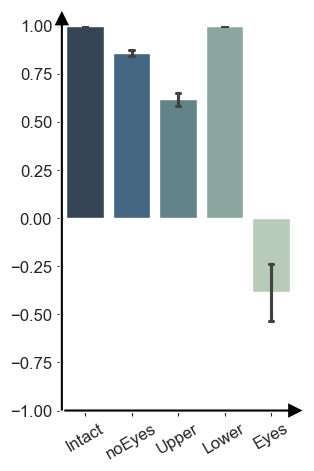

100%|██████████| 30/30 [00:17<00:00,  1.72it/s]


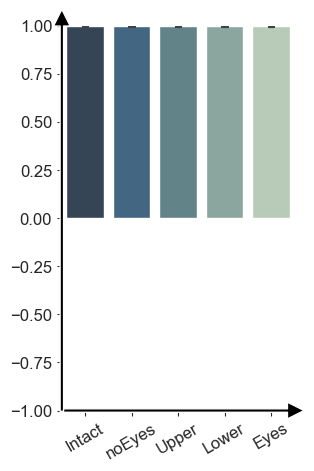

In [15]:
ACC_test = FFA_decoding(Dynamics_states_recurrent_VTC)
data = pd.DataFrame(2*ACC_test[:,:5] - 1)
barplot(data)

ACC_test = FFA_decoding(Dynamics_states_feedback_VTC)
data = pd.DataFrame(2*ACC_test[:,:5] - 1)
barplot(data)

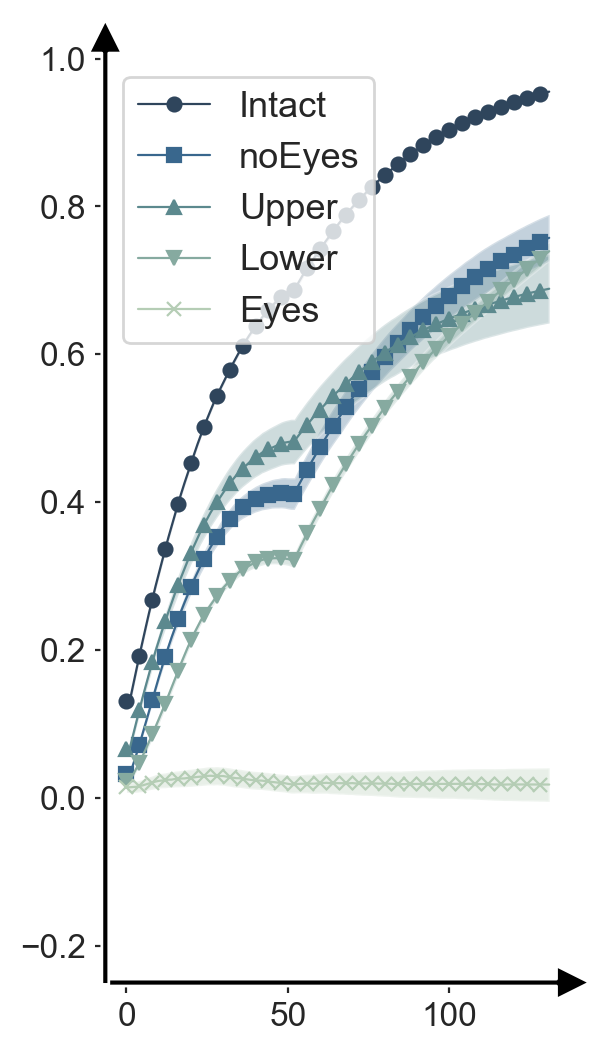

In [16]:
plot_6_condition_timeseries(mode='double', region='face', Dynamics_states=Dynamics_states_recurrent_VTC)

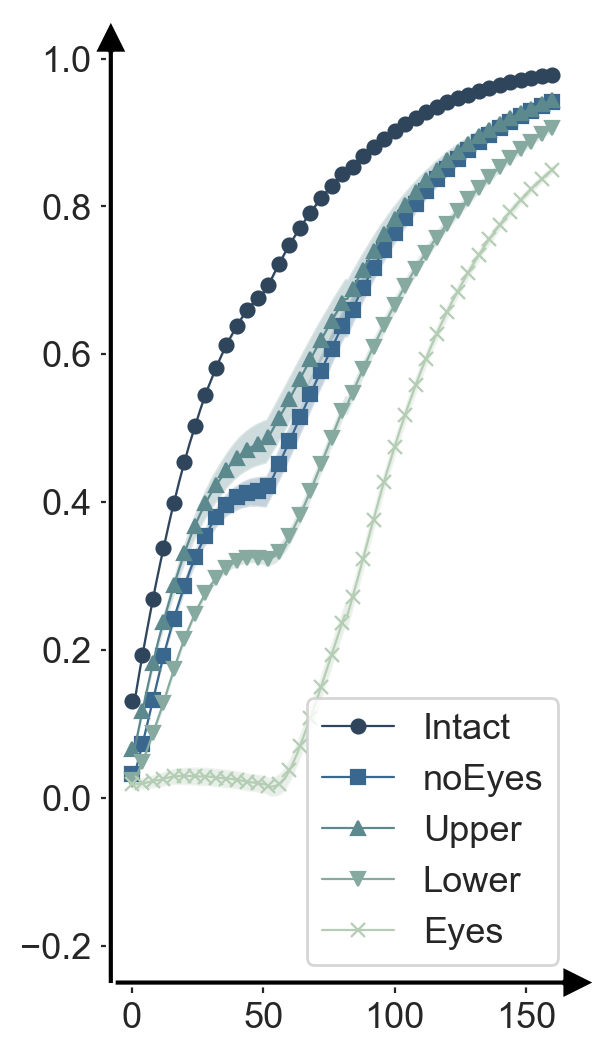

In [17]:
plot_6_condition_timeseries(mode='double', region='face', Dynamics_states=Dynamics_states_feedback_VTC)